In [ ]:
!pip install umap-learn

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.2/88.2 KB 9.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 64.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for umap-learn: filename=umap_learn-0.5.3-py3-none-any.whl size=82830 sha256=9ebe14a0ea0fd64ec07a6b8e5910fc8668026de9d70a386caac851c8b766c992
  Stored in directory: /root/.cache/pip/wheels/f4/3e/1c/596d0a463d17475af648688443fa4846fef624d1390339e7e9
  Created wheel for pynndescent: filename=pynndescent-0.5.8-py3-none-any.whl size=55509 sha256=baf2a1dbd04838e1a8b12ef3954f905554b76662dac72cbeeb86eeadfd96562c
  Stored in directory: /root/.cache/pip/wheels/b9/89/cc/59ab91ef5b21dc2ab3635528d7d227f49dfc9169905dcb959d
Successfully built umap-learn pynndescent


In [ ]:
import numpy as np
import tensorflow as tf

from umap import UMAP
from matplotlib import pyplot as plt
from skimage import io

# 1. Вывод фильтров свертки


В этом разделе нужно:

1) создать модель VGG16 с весами 'imagenet'

2) загрузить свою зартинку в переменную при помощи skiamge.io.imread или plt.imread и тд

3) создать новую модель нейронной сети с выходами, которые соответствуют выходам сверточных слоев с названиями ['block1_pool', 'block2_pool', 'block3_pool', 'block4_pool', 'block5_pool']

4) отправить новой модели свою картинку и сохранить возвращенный результат

5) вывести по одному фильтру свертки для каждого сверточного слоя при помощи plt.imshow

1/1 [==============================] - 10s 10s/step


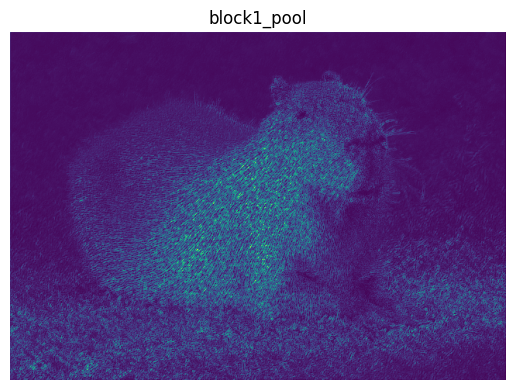

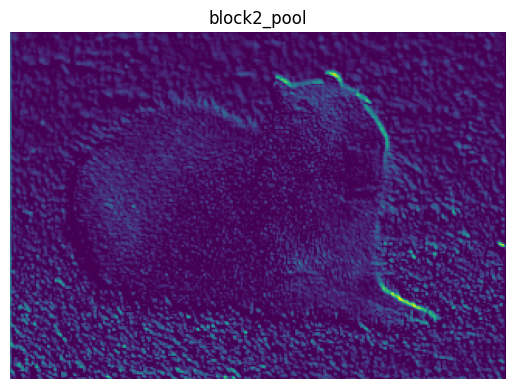

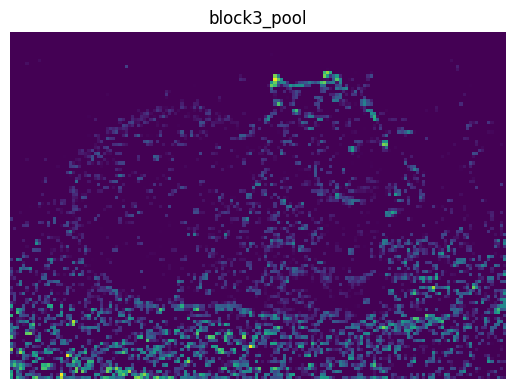

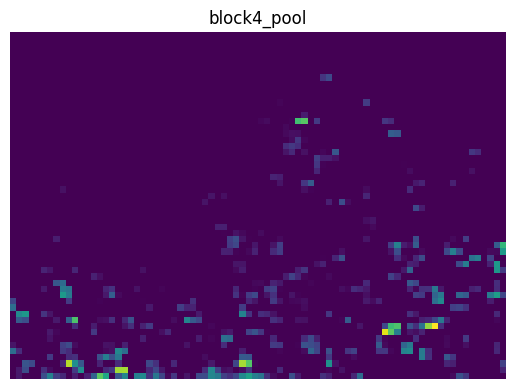

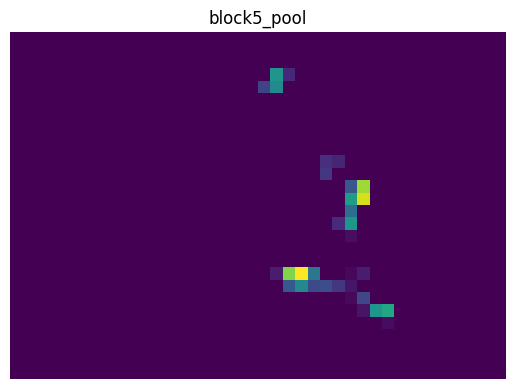

In [ ]:
from skimage.io import imread

vgg = tf.keras.applications.VGG16(weights='imagenet', include_top=False)
img = imread('/content/capy.jpg')
layers_name = ['block1_pool', 'block2_pool', 'block3_pool', 'block4_pool', 'block5_pool']
outputs = [vgg.get_layer(i).output for i in layers_name]
model = tf.keras.models.Model(inputs=vgg.input, outputs=outputs)

img = np.expand_dims(img, axis=0)
result = model.predict(img)

for i, block in enumerate(['block1_pool', 'block2_pool', 'block3_pool',  'block4_pool', 'block5_pool']):
    plt.figure()
    plt.imshow(result[i][0, :, :, 0])
    plt.title(block)
    plt.axis('off')
    plt.show()



# 2. Выбор датасета

1) Переходим на [сайт](https://www.tensorflow.org/datasets/catalog/overview) датасетов tensorflow и выбираем датасет с изображениями для классификации

2) загружаем датасет в переменную

In [ ]:
import tensorflow_datasets as tfds
dataset, info = tfds.load('oxford_iiit_pet', split='train', as_supervised=True)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Shuffling /root/tensorflow_datasets/oxford_iiit_pet/3.2.0.incompleteIZU88M/oxford_iiit_pet-train.tfrecord*...:…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_iiit_pet/3.2.0.incompleteIZU88M/oxford_iiit_pet-test.tfrecord*...: …

Dataset oxford_iiit_pet downloaded and prepared to /root/tensorflow_datasets/oxford_iiit_pet/3.2.0. Subsequent calls will reuse this data.


# 3. Получение признаков для всего датасета

1) создаем модель VGG16 без последнего классифицирубщего слоя (include_top=False)

2) В цикле загружаем картинки нашего датасета в модель и сохраняем вектор признаков (эмбеддинг)

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import img_to_array, load_img
from tensorflow.keras.applications.vgg16 import preprocess_input

model = tf.keras.applications.VGG16( include_top=False)
features = []
dataset = dataset.take(5000)
for image, label in dataset:
    image = tf.cast(image, tf.float32)
    image = tf.image.resize(image, (224, 224))
    image = preprocess_input(image)
    feature_vector = model.predict(np.expand_dims(image, axis=0))
    features.append(feature_vector.flatten())

np.save('features.npy', features)

1/1 [==============================] - 0s 391ms/step


# 4. Вывод признаков датасета на двумерную плоскость

1) создаем модель для понижения размерности и загружаем в нее вектора признаков изображений. Размер входных данных для Umap - (N_images, N_features). Документация [Umap](https://umap-learn.readthedocs.io/en/latest/basic_usage.html)

2) при помощи plt.scatter выводим выводит признаки на двумерную плоскость так, чтобы у каждого класса был свой цвет

(!) обратите внимание, что признаки изображений хранятся в тензорах Tensorflow. Перед их обработкой нужно получить их версии в numpy

In [ ]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import umap


In [ ]:
seed = 51
# создаем модель Umap
umap_2d = umap.UMAP()

# понижаем размерность
umaped_vct_2d = umap_2d.fit_transform(features)
x,y=umaped_vct_2d[:,0],umaped_vct_2d[:,1]

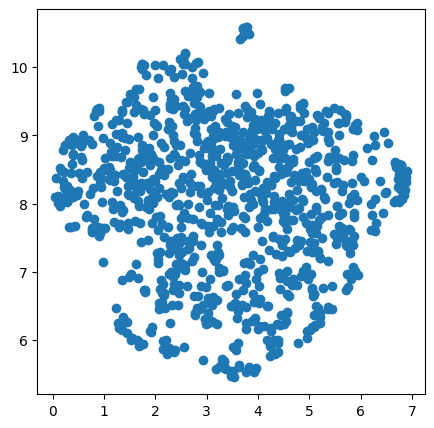

In [ ]:
plt.figure(figsize=(5,5))
plt.scatter(x,y)


plt.show()

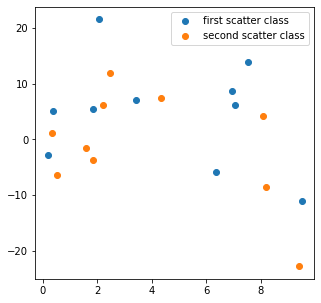

In [ ]:
x1=np.random.uniform(0,10,10)
y1=np.random.normal(2,10,10)

x2=np.random.uniform(0,10,10)
y2=np.random.normal(1,8,10)

plt.figure(figsize=(5,5))

plt.scatter(x1,y1)
plt.scatter(x2,y2)

plt.legend(['first scatter class','second scatter class'])
plt.show()

Как понять, что все хорошо? Если все шаги были выполнены верно, то на двумерной плоскости у вас должны появиться K кластеров вашего датасета, где каждый кластер будет отвечать за свой класс в датасета. Т.е. собачки будут отдельно, котики отдельно и тд